# Testing Random Forest with Various Run Splits

### Imports

In [956]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

In [957]:
from venus_ml import RandomForest, VenusDataset, ExtraTrees
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Testing Parameters

In [958]:
run1 = '00'
run2 = '09'
random_state = 88
rf_args = {
    "n_estimators":400, 
    "n_jobs": -1,
    "random_state": random_state
}

### Dataset Config + Initialization

In [959]:
def get_features(names, mean=True, std=False):
    out_list = []
    for name in names:
        if mean:
            out_list.append(name + "_mean")
        if std:
            out_list.append(name + "_std")
    return out_list

def standardize_data(train_x, valid_x):
    mu = train_x.mean()
    sigma = train_x.std()
    train_x = (train_x - mu)/sigma
    valid_x = (valid_x - mu)/sigma
    return train_x, valid_x

In [960]:
tiny_list = ["inj_mbar", "bias_v", "bias_i", "extraction_i"]
less_tiny_list = tiny_list + ["ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i"]
even_less_tiny_list = less_tiny_list + ["inj_i", "ext_i", "mid_i", "sext_i", "x_ray_source", "x_ray_exit"]
data_set_config = {
    "file_path": "../../minmax_watch_data.parquet",
    "input_columns": get_features(even_less_tiny_list, std=False),
    "output_columns": ["fcv1_i_mean"],
    "run_selection": (run1, run2),
}
dataset = VenusDataset(**data_set_config)


for run_id in dataset.df.run_id.unique():
    grouped_df = dataset.df[dataset.df['run_id']==run_id]
    print(f"Set {run_id} | Size: {grouped_df.shape} | Min: {grouped_df['fcv1_i_mean'].min()} | Max: {grouped_df['fcv1_i_mean'].max()}")

Set 00 | Size: (2549, 170) | Min: 0.0 | Max: 1.0
Set 09 | Size: (624, 170) | Min: 0.0 | Max: 1.0


## Train and Validation with Run 5

In [961]:
train_inputs, train_outputs, valid_inputs, valid_outputs = dataset.get_run_splits((run1,), random_state=random_state)
# train_inputs, valid_inputs = standardize_data(train_inputs, valid_inputs)
train_outputs, valid_outputs = train_outputs.ravel(), valid_outputs.ravel()
print(train_inputs.shape, train_outputs.shape, valid_inputs.shape, valid_outputs.shape)

(2039, 15) (2039,) (510, 15) (510,)


In [962]:
rf = RandomForest(rf_args)
rf.fit(train_inputs, train_outputs)
mse = rf.evaluate(valid_inputs, valid_outputs)
score = rf.model.score(valid_inputs, valid_outputs)
print(f"MSE: {mse} | Score: {score} | Max Depth: {max([estimator.tree_.max_depth for estimator in rf.model.estimators_])}")

MSE: 0.0008780708325276948 | Score: 0.9882353437687903 | Max Depth: 31


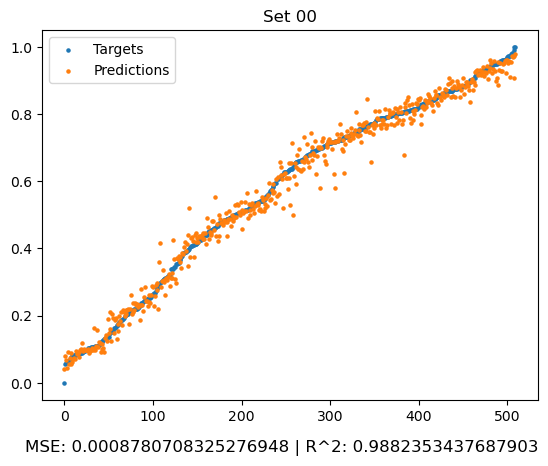

In [963]:
x_axis = range(valid_inputs.shape[0])
indices = np.argsort(valid_outputs)
targets = valid_outputs[indices]
predictions = rf.predict(valid_inputs)[indices]
plt.scatter(x_axis, targets, s=5, label="Targets", )
plt.scatter(x_axis, predictions,s=5, label="Predictions")
txt = f"MSE: {mse} | R^2: {score}"
plt.title(f"Set {run1}")
plt.figtext(0.5, 0.001, txt, wrap=True, horizontalalignment='center', fontsize=12)
plt.legend()
plt.show()

## Train and Validation with Runs 5 & 9

In [964]:
train_inputs, train_outputs, valid_inputs, valid_outputs = dataset.get_run_splits((run1, run2), random_state=random_state)
# train_inputs, valid_inputs = standardize_data(train_inputs, valid_inputs)
train_outputs, valid_outputs = train_outputs.ravel(), valid_outputs.ravel()
print(train_inputs.shape, train_outputs.shape, valid_inputs.shape, valid_outputs.shape)

(2538, 15) (2538,) (635, 15) (635,)


In [965]:
rf = RandomForest(rf_args)
rf.fit(train_inputs, train_outputs)
mse = rf.evaluate(valid_inputs, valid_outputs)
score = rf.model.score(valid_inputs, valid_outputs)
print(f"MSE: {mse} | Score: {score} | Max Depth: {max([estimator.tree_.max_depth for estimator in rf.model.estimators_])}")

MSE: 0.0010555108088689071 | Score: 0.9859256108207094 | Max Depth: 32


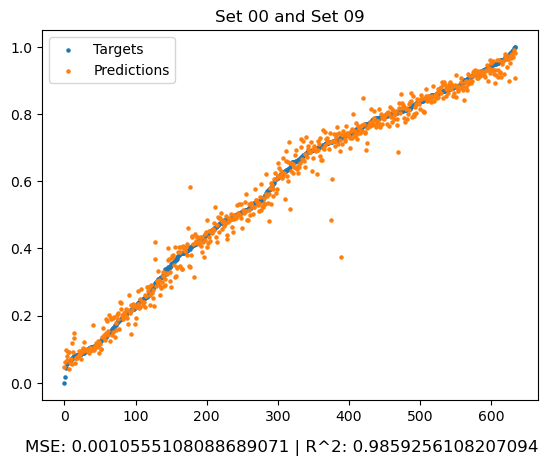

In [966]:
x_axis = range(valid_inputs.shape[0])
indices = np.argsort(valid_outputs)
targets = valid_outputs[indices]
predictions = rf.predict(valid_inputs)[indices]
plt.scatter(x_axis, targets, s=5, label="Targets", )
plt.scatter(x_axis, predictions,s=5, label="Predictions")
plt.title(f"Set {run1} and Set {run2}")
txt = f"MSE: {mse} | R^2: {score}"
plt.figtext(0.5, 0.001, txt, wrap=True, horizontalalignment='center', fontsize=12)
plt.legend()
plt.show()

## Train on 5 and Validate on 9

In [967]:
data = dataset.get_runs((run1,run2))
train_inputs, train_outputs, valid_inputs, valid_outputs = data[run1][0], data[run1][1], data[run2][0], data[run2][1]
# train_inputs, valid_inputs = standardize_data(train_inputs, valid_inputs)
train_outputs, valid_outputs = train_outputs.ravel(), valid_outputs.ravel()
print(train_outputs.min(), train_outputs.max())
print(valid_outputs.min(), valid_outputs.max())

0.0 1.0
0.0 1.0


In [968]:
rf = RandomForest(rf_args)
rf.fit(train_inputs, train_outputs)
mse = rf.evaluate(valid_inputs, valid_outputs)
score = rf.model.score(valid_inputs, valid_outputs)
print(f"MSE: {mse} | Score: {score} | Max Depth: {max([estimator.tree_.max_depth for estimator in rf.model.estimators_])}")

MSE: 0.018878265339452246 | Score: 0.7931917956226167 | Max Depth: 31


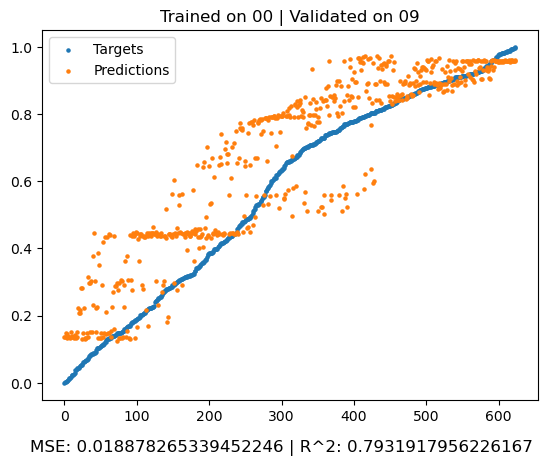

In [969]:
x_axis = range(valid_inputs.shape[0])
indices = np.argsort(valid_outputs)
targets = valid_outputs[indices]
predictions = rf.predict(valid_inputs)[indices]
plt.scatter(x_axis, targets, s=5, label="Targets", )
plt.scatter(x_axis, predictions,s=5, label="Predictions")
plt.title(f"Trained on {run1} | Validated on {run2}")
txt = f"MSE: {mse} | R^2: {score}"
plt.figtext(0.5, 0.001, txt, wrap=True, horizontalalignment='center', fontsize=12)
plt.legend()
plt.show()

### Distribution of current values

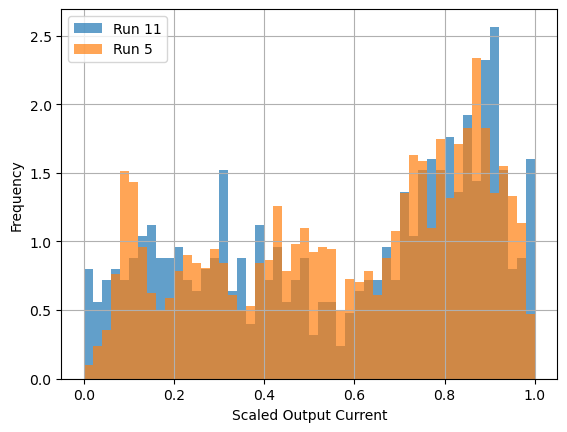

In [970]:
plt.hist(valid_outputs, bins=50, alpha=0.7, density=True, label="Run 11")
plt.hist(train_outputs, bins=50, alpha=0.7, density=True, label="Run 5")
plt.xlabel('Scaled Output Current')
plt.ylabel('Frequency')
plt.legend(loc='best')
plt.grid(True)
plt.show()